## <span style="color:#db7d60">Purpose</span>

The goal of this notebook is to organize figure out all the figures we need for this. This is more of an experimental notebook.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
import time
import json
import pickle
from collections import Counter, defaultdict
from types import SimpleNamespace
from itertools import islice
from pathlib import Path
# Math
import math
import numpy as np
import pandas as pd
from numba import njit, float64, types
from numba.experimental import jitclass
from numba.typed import Dict
from scipy.signal import savgol_filter
from numerize import numerize
# Plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

from particle import Particle
import vector
import jetnet
import jetnet.evaluation

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
root_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))
sys.path.insert(0, str(root_dir))

# particleGPT
import pUtil
import data_manager
from analysis_common import *
import analysis_v2 as analv2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Set basic themeing and display options for optimal display of information

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option("display.float_format", "{:,.0f}".format)

# Set use_text=True if a latex installation is avaliable.
analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

# We want larger fonts for these figures
analv2.plotting_v2.ticks_fontsize = 14
analv2.plotting_v2.axes_fontsize = 12

<Figure size 640x480 with 0 Axes>

## <span style="color:#db7d60">Main</span>

In [ ]:
model_names_and_labels = {
    'model_exp11_100k_lr1': '16.6M - 20M',
    'model_exp11_500k_lr1': '83M - 20M',
    'model_exp11_1M_lr1': '166M - 20M',
    'model_exp11_2M_lr1': '332M - 20M',
    'model_exp11_5M_lr1': '830M - 20M',
    'model_exp11_5M_lr1_tp2': '830M - 208M',
    'model_10M_9_exp9_vdimlr_1': '1.47B - 20M',
    'model_exp11_9M_lr1_tp2': '1.47B - 208M',
    'model_exp11_9M_lr1_tp3': '1.47B - 108M',
    'model_exp11_9M_lr1_tp4': '1.47B - 76M',
    'model_exp11_9M_lr1_tp6': '1.47B - 39M',
    'model_exp11_9M_lr1_tp5': '1.47B - 611M',
    'model_exp11_22M_lr1_tp1': '3.8B - 20M',
    'model_exp11_22M_lr1_tp2': '3.8B - 208M',
    'model_exp11_22M_lr1_tp3': '3.8B - 108M',
    'model_exp11_22M_lr1_tp4': '3.8B - 76M',
    'model_exp11_22M_lr1_tp6': '3.8B - 39M',
    'model_exp11_22M_lr1_tp5': '3.8B - 611M',
    'model_exp11_45M_lr1_tp1': 'N/A B - 20M',
    'model_exp11_45M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_45M_lr1_tp4': 'N/A B - 76M',
    'model_exp11_45M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_45M_lr1_tp2': 'N/A B - 208M',
    'model_exp11_45M_lr1_tp5': 'N/A B - 611M'
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df1 = analv2.tables.get_default_df(model_names)
df1["compute"] = df1["num_params"] * df1["batch_size"] * df1["iters_saved"]

### Stopping condition

I need to identify the stopping condition. I did not strictly define one, but I need one for consistency.

In [5]:
def analyze_checkpoint_cases(logfile_path):
    logfile_path = Path(logfile_path)

    events = []
    max_step = 0

    with logfile_path.open("r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                continue

            msg = rec.get("message", "")

            if msg.startswith("Training progress: checking checkpoint conditions"):
                step = rec.get("step", 0)
                max_step = max(max_step, step)
                events.append(("check", line_num))

            elif msg.startswith("Training progress: saving best checkpoint"):
                events.append(("best", line_num))

            elif msg.startswith("Training progress: saving current checkpoint"):
                events.append(("current", line_num))

    case2_between_case1s = []
    trailing_case2s = 0
    max_consecutive_case2s = 0
    global_case2_run = 0

    seen_first_case1 = False
    current_case2_run = 0

    i = 0
    while i < len(events):
        kind, _ = events[i]

        if kind != "check":
            i += 1
            continue

        has_best = False
        has_current = False

        j = i + 1
        while j < len(events) and events[j][0] != "check":
            if events[j][0] == "best":
                has_best = True
            elif events[j][0] == "current":
                has_current = True
            j += 1

        if has_current:
            if has_best:
                if seen_first_case1:
                    case2_between_case1s.append(current_case2_run)

                seen_first_case1 = True
                current_case2_run = 0
                global_case2_run = 0

            else:
                global_case2_run += 1
                max_consecutive_case2s = max(max_consecutive_case2s, global_case2_run)

                if seen_first_case1:
                    current_case2_run += 1

        i = j

    if seen_first_case1:
        trailing_case2s = current_case2_run
        max_case2_between_case1s = max(case2_between_case1s, default=0)
    else:
        trailing_case2s = 0
        max_case2_between_case1s = 0

    return {
        "model_names": logfile_path.parent.name,
        "max_case2s_between_case1s": max_case2_between_case1s,
        "case2s_after_last_case1": trailing_case2s,
        "max_consecutive_case2s": max_consecutive_case2s,
        "total_steps_trained": max_step,
    }

In [6]:
rows = []
for mn in model_names:
    logfile_path = root_dir / 'trained_models' / mn / 'train_log_1.jsonl'
    res = analyze_checkpoint_cases(logfile_path)
    rows.append(res)

table = pd.DataFrame(rows)
display(table)

,model_names,max_case2s_between_case1s,case2s_after_last_case1,max_consecutive_case2s,total_steps_trained
0,model_exp11_100k_lr1,0,52,52,13500
1,model_exp11_500k_lr1,1,47,47,13750
2,model_exp11_1M_lr1,4,126,126,35750
3,model_exp11_2M_lr1,20,52,52,35750
4,model_exp11_5M_lr1,123,4,123,67250
5,model_exp11_5M_lr1_tp2,4,28,28,15250
6,model_10M_9_exp9_vdimlr_1,43,104,104,65500
7,model_exp11_9M_lr1_tp2,6,23,23,22000
8,model_exp11_9M_lr1_tp3,13,15,15,25000
9,model_exp11_9M_lr1_tp4,7,96,96,45250


### Tracking trained models

We need a 2D matrix to easily track which model corresponds to what (num_params, num_train_tokens) tuple.

This way we can keep track of what is left to train to attain perfect results.

In [7]:
def fmt_tokens(x):
    if x >= 1e9:
        return f"{x/1e9:.2f}B"
    else:
        return f"{x/1e6:.1f}M"
    
matrix = df1.pivot(index="num_params", columns="num_train_tokens", values="model_name")
matrix.columns = matrix.columns.map(fmt_tokens)
matrix.index = matrix.index.map(fmt_tokens)
display(matrix)

num_train_tokens,16.6M,83.0M,166.0M,332.0M,830.0M,1.47B,3.78B,7.57B
num_params,,,,,,,,
20.1M,model_exp11_100k_lr1,model_exp11_500k_lr1,model_exp11_1M_lr1,model_exp11_2M_lr1,model_exp11_5M_lr1,model_10M_9_exp9_vdimlr_1,model_exp11_22M_lr1_tp1,model_exp11_45M_lr1_tp1
39.0M,NaN,NaN,NaN,NaN,NaN,model_exp11_9M_lr1_tp6,model_exp11_22M_lr1_tp6,model_exp11_45M_lr1_tp6
70.5M,NaN,NaN,NaN,NaN,NaN,model_exp11_9M_lr1_tp4,model_exp11_22M_lr1_tp4,model_exp11_45M_lr1_tp4
108.3M,NaN,NaN,NaN,NaN,NaN,model_exp11_9M_lr1_tp3,model_exp11_22M_lr1_tp3,model_exp11_45M_lr1_tp3
209.0M,NaN,NaN,NaN,NaN,model_exp11_5M_lr1_tp2,model_exp11_9M_lr1_tp2,model_exp11_22M_lr1_tp2,model_exp11_45M_lr1_tp2
611.7M,NaN,NaN,NaN,NaN,NaN,model_exp11_9M_lr1_tp5,model_exp11_22M_lr1_tp5,model_exp11_45M_lr1_tp5


In [8]:
disp_df = df1[['model_name', 'iters_saved', 'min_saved_train_loss', 'min_saved_val_loss', 'num_train_tokens', 'num_params', 'compute']]

sorting_key = 'num_params'
print(f"Sorted by: {sorting_key}")
display(disp_df.sort_values(by=[sorting_key, 'min_saved_val_loss'], ascending=True)
    .style.format({"num_train_tokens": "{:,}", "num_params": "{:,}" , "compute": "{:,}"}))

Sorted by: num_params


,model_name,iters_saved,min_saved_train_loss,min_saved_val_loss,num_train_tokens,num_params,compute
4,model_exp11_5M_lr1,66250,4.465939,4.463429,"830,000,000","20,148,224","170,856,939,520,000"
6,model_10M_9_exp9_vdimlr_1,39500,4.473144,4.479452,"1,467,326,290","20,148,224","101,869,420,544,000"
18,model_exp11_45M_lr1_tp1,29500,4.482624,4.482099,"7,574,509,800","20,148,224","76,079,693,824,000"
12,model_exp11_22M_lr1_tp1,23000,4.484218,4.485573,"3,779,621,390","20,148,224","59,316,371,456,000"
3,model_exp11_2M_lr1,22750,4.438519,4.500669,"332,000,000","20,148,224","58,671,628,288,000"
2,model_exp11_1M_lr1,4250,4.504503,4.558721,"166,000,000","20,148,224","10,960,633,856,000"
1,model_exp11_500k_lr1,2000,4.515970,4.626153,"83,000,000","20,148,224","5,157,945,344,000"
0,model_exp11_100k_lr1,500,4.617033,4.753753,"16,600,000","20,148,224","1,289,486,336,000"
16,model_exp11_22M_lr1_tp6,41500,4.441773,4.445516,"3,779,621,390","39,028,736","207,320,645,632,000"
19,model_exp11_45M_lr1_tp6,28750,4.444906,4.446852,"7,574,509,800","39,028,736","143,625,748,480,000"


### Reproduction of Figure 4

The goal here is to reproduce Figure 4 from [Kaplan's Scaling Laws Paper](https://arxiv.org/abs/2001.08361):

![Screenshot 2026-03-25 014509.png](<attachment:Screenshot 2026-03-25 014509.png>)
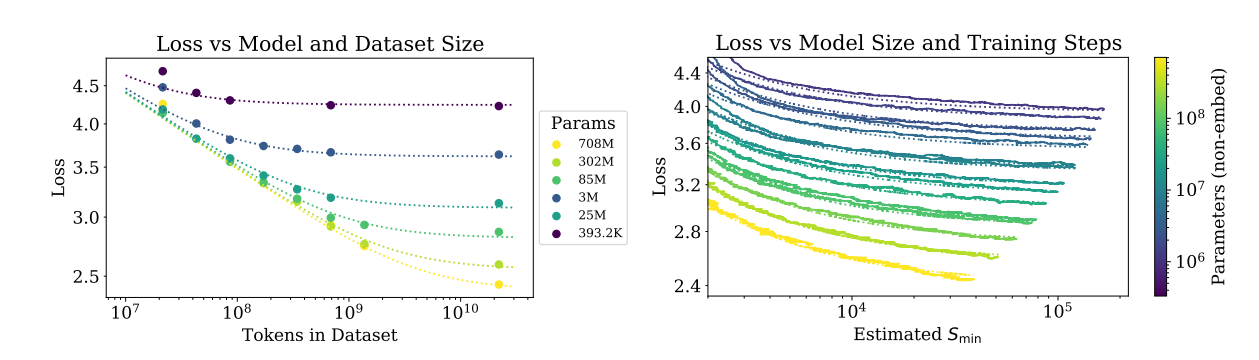

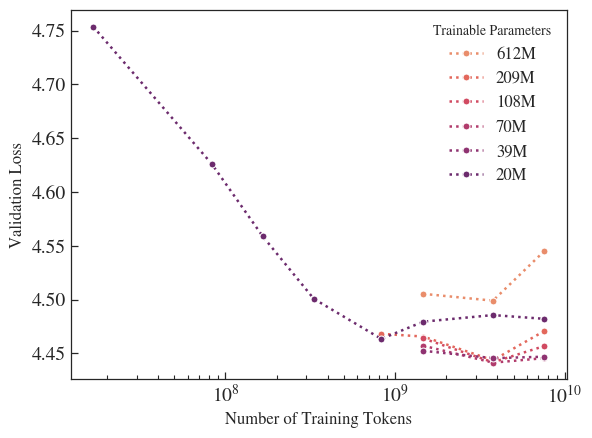

In [9]:
df_plot1 = df1[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_plot1["num_params_label"] = df_plot1["num_params"].map(lambda x: f"{x/1e6:.0f}M")

order = (df_plot1.sort_values("num_params")["num_params_label"].drop_duplicates().iloc[::-1])

plt.figure()
sns.lineplot(
    data=df_plot1, x="num_train_tokens", y="min_saved_val_loss", hue="num_params_label", hue_order=order,
    palette="flare", marker="o", estimator=None, linestyle=':'
)
plt.xlabel("Number of Training Tokens", fontsize=analv2.plotting_v2.axes_fontsize)
plt.ylabel("Validation Loss", fontsize=analv2.plotting_v2.axes_fontsize)
plt.xticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.yticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.legend_fontsize)
plt.xscale("log")
plt.show()

### Reproduction of Figure 1

The goal here is to reproduce Figure 1 from [Kaplan's Scaling Laws Paper](https://arxiv.org/abs/2001.08361):

![Screenshot 2026-03-25 185905.png](<attachment:Screenshot 2026-03-25 185905.png>)

I must account for the figure caption: (model size, dataset size, compute) must not bottle neck each other $\implies$ the figure uses best case cherry-picked models. I will do the same.
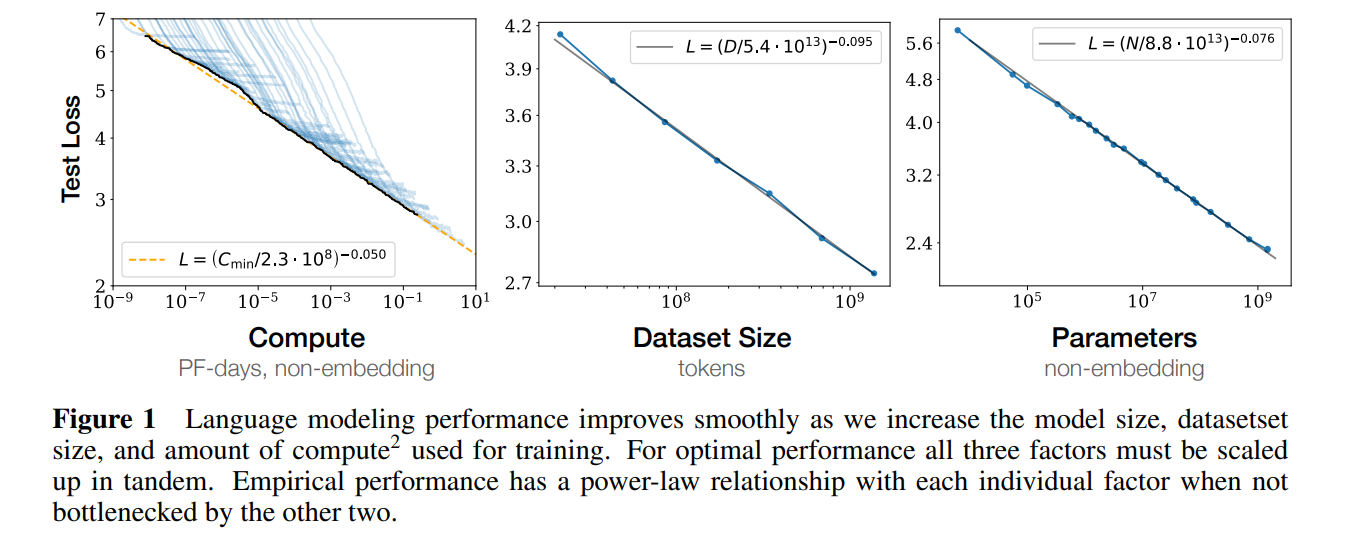

##### Dataset size vs. Loss

In [10]:
model_names_and_labels = {
    'model_exp11_22M_lr1_tp4': 'PLACEHOLDER',
    'model_exp11_45M_lr1_tp4': 'PLACEHOLDER',
    'model_exp11_9M_lr1_tp6': 'PLACEHOLDER',
    'model_exp11_5M_lr1': 'PLACEHOLDER',
    'model_exp11_1M_lr1': 'PLACEHOLDER',
    'model_exp11_500k_lr1': 'PLACEHOLDER',
    'model_exp11_100k_lr1': 'PLACEHOLDER',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df2 = analv2.tables.get_default_df(model_names)

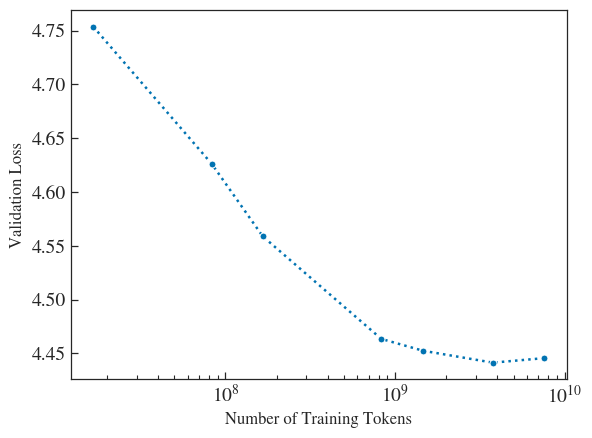

In [11]:
df_plot2 = df2[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_plot2["num_params_label"] = df_plot2["num_params"].map(lambda x: f"{x/1e6:.0f}M")

plt.figure()
sns.lineplot(
    data=df_plot2, x="num_train_tokens", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
plt.xlabel("Number of Training Tokens", fontsize=analv2.plotting_v2.axes_fontsize)
plt.ylabel("Validation Loss", fontsize=analv2.plotting_v2.axes_fontsize)
plt.xticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.yticks(fontsize=analv2.plotting_v2.ticks_fontsize)
# plt.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.legend_fontsize)
plt.xscale("log")
plt.show()

##### Parameters vs. Loss

In [12]:
model_names_and_labels = {
    'model_exp11_22M_lr1_tp4': 'PLACEHOLDER',
    'model_exp11_22M_lr1_tp3': 'PLACEHOLDER',
    'model_exp11_22M_lr1_tp2': 'PLACEHOLDER',
    'model_exp11_22M_lr1_tp6': 'PLACEHOLDER',
    'model_exp11_5M_lr1': 'PLACEHOLDER',
    'model_exp11_22M_lr1_tp5': 'PLACEHOLDER',
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df3 = analv2.tables.get_default_df(model_names)

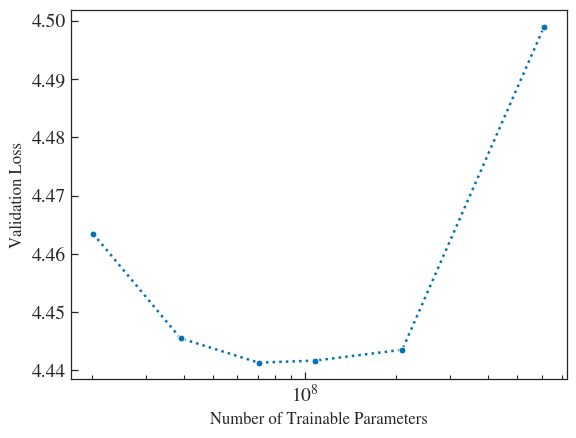

In [13]:
df_plot3 = df3[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params"]].copy()
df_plot3["num_params_label"] = df_plot3["num_params"].map(lambda x: f"{x/1e6:.0f}M")

plt.figure()
sns.lineplot(
    data=df_plot3, x="num_params", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
plt.xlabel("Number of Trainable Parameters", fontsize=analv2.plotting_v2.axes_fontsize)
plt.ylabel("Validation Loss", fontsize=analv2.plotting_v2.axes_fontsize)
plt.xticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.yticks(fontsize=analv2.plotting_v2.ticks_fontsize)
# plt.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.legend_fontsize)
plt.xscale("log")
plt.show()

##### Compute vs. Loss

In [14]:
model_names_and_labels = {
    'model_exp11_100k_lr1': '16.6M - 20M',
    'model_exp11_500k_lr1': '83M - 20M',
    'model_exp11_1M_lr1': '166M - 20M',
    'model_exp11_2M_lr1': '332M - 20M',
    'model_exp11_5M_lr1': '830M - 20M',
    'model_exp11_5M_lr1_tp2': '830M - 208M',
    'model_10M_9_exp9_vdimlr_1': '1.47B - 20M',
    'model_exp11_9M_lr1_tp2': '1.47B - 208M',
    'model_exp11_9M_lr1_tp3': '1.47B - 108M',
    'model_exp11_9M_lr1_tp4': '1.47B - 76M',
    'model_exp11_9M_lr1_tp6': '1.47B - 39M',
    'model_exp11_9M_lr1_tp5': '1.47B - 611M',
    'model_exp11_22M_lr1_tp1': '3.8B - 20M',
    'model_exp11_22M_lr1_tp2': '3.8B - 208M',
    'model_exp11_22M_lr1_tp3': '3.8B - 108M',
    'model_exp11_22M_lr1_tp4': '3.8B - 76M',
    'model_exp11_22M_lr1_tp6': '3.8B - 39M',
    'model_exp11_22M_lr1_tp5': '3.8B - 611M',
    'model_exp11_45M_lr1_tp1': 'N/A B - 20M',
    'model_exp11_45M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_45M_lr1_tp4': 'N/A B - 76M',
    'model_exp11_45M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_45M_lr1_tp2': 'N/A B - 208M',
    'model_exp11_45M_lr1_tp5': 'N/A B - 611M'
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df4 = analv2.tables.get_default_df(model_names)
df4["compute"] = df4["num_params"] * df4["batch_size"] * df4["iters_saved"]

I am using roughly Kaplan's definition of compute, which is
$$
C_{kaplan} = 6NBS
$$
$ N $ = number of non-embedding and non-vocab trainable parameters, $ B $ = batch size, $ S $ training steps (number of time model parameters were updated). I do not know why it is multiplied by 6. C is reported in "petaflop days" which they define as $ \text{PF-day} = 1015 × 24 × 3600 = 8.64 × 1019 $.

Mine is,
$$
C_{ours} = NBS
$$
$ N $ = number of all trainable parameters, $ B $ = batch size, $ S $ training steps (number of time model parameters were updated).

$ C_{ours} $ should still provide roughly the same information.

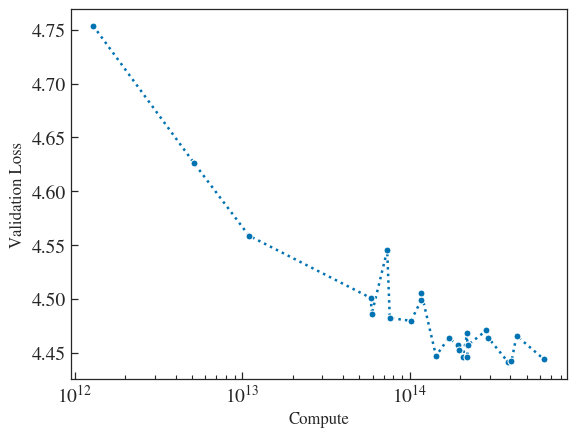

In [15]:
df_plot4 = df4[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params", "batch_size", "compute"]].copy()
df_plot4["num_params_label"] = df_plot4["num_params"].map(lambda x: f"{x/1e6:.0f}M")

plt.figure()
sns.lineplot(
    data=df_plot4, x="compute", y="min_saved_val_loss",
    marker="o", estimator=None, linestyle=':'
)
plt.xlabel("Compute", fontsize=analv2.plotting_v2.axes_fontsize)
plt.ylabel("Validation Loss", fontsize=analv2.plotting_v2.axes_fontsize)
plt.xticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.yticks(fontsize=analv2.plotting_v2.ticks_fontsize)
# plt.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.legend_fontsize)
plt.xscale("log")
plt.show()

### Kinematic Reconstructions (Combined)

Kinematic reconstructions for models with significant variation in vocab size (all particles).

For this, we have chosen two models to showcase: `model_10M_9_exp9_vdimlr_1` (14.7k tokens) and `model_10M_12_inclrrestarts_3` (1.9k tokens).

In [21]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']

real_verbose_data = data_manager.load_verbose_dataset(
    pUtil.get_model_preparation_dir(models_to_compare[0]) / "real_verbose_test_particles.csv",
    pad_token=np.nan
)

gen_verbose_data_dict = {}
for mn in models_to_compare:
    sampled_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
        pad_token=np.nan
    )
    gen_verbose_data_dict[mn] = sampled_verbose_data

(<Figure size 1800x600 with 6 Axes>,
 (<Axes: ylabel='Density'>, <Axes: xlabel='$\\phi$', ylabel='Gen / Geant4'>))

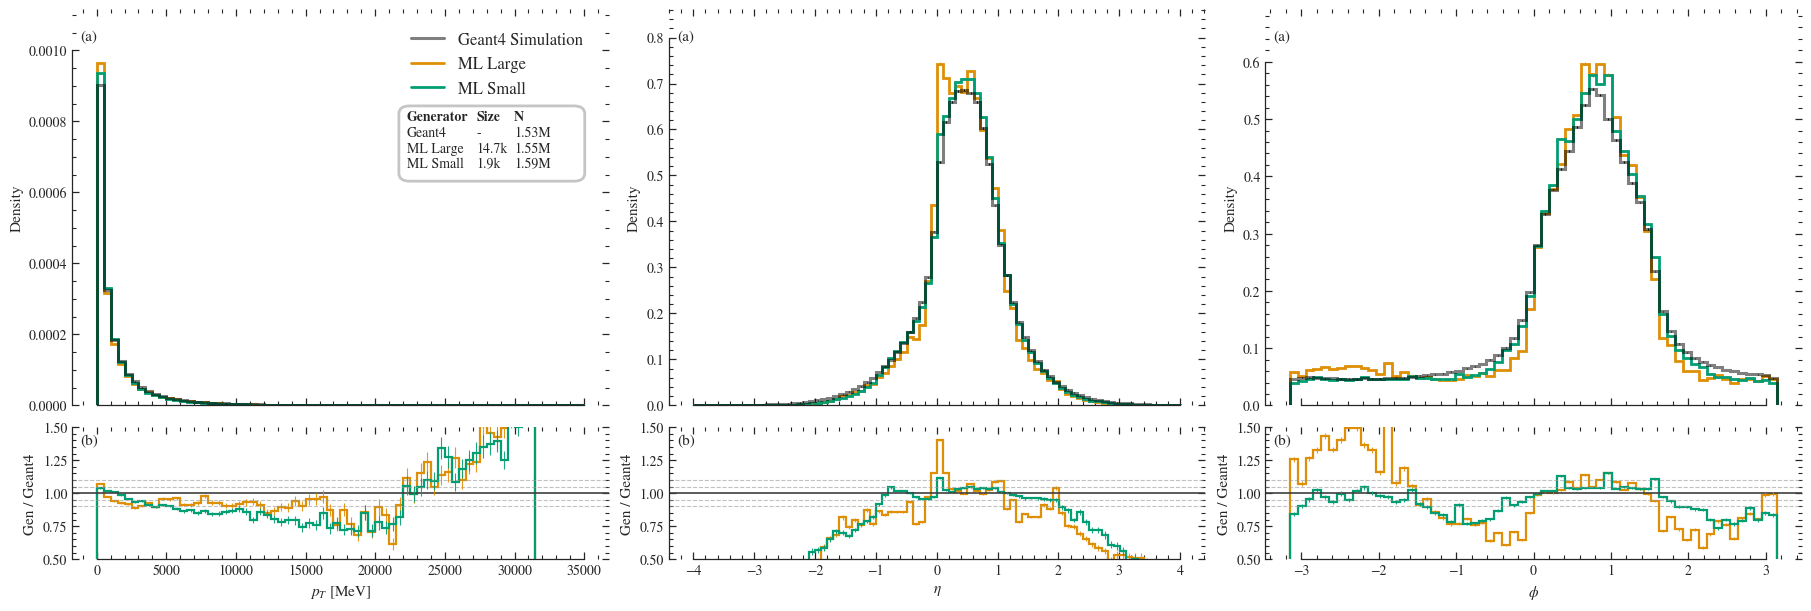

In [22]:
all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

cn_data_dict = {}
for column_name in all_columns:
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=False)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=False)
        gen_data_dict[mn] = pdata_gen
        
    cn_data_dict[column_name] = (pdata_real, gen_data_dict)
    
# Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

fig, axes = plt.subplots(
    2, 3, sharex='col', figsize=(18, 6), 
    gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=True
)

# pt
cn = 'pt'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=False,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
    fig_ax_tuple=(fig, axes[0][0], axes[1][0]),
)

cn = 'eta'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=False,
    show_legend=False,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    fig_ax_tuple=(fig, axes[0][1], axes[1][1]),
)

cn = 'phi'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=False,
    show_legend=False,
    # spec_text=spec_text,
    # spec_table_rows=spec_table_rows,
    fig_ax_tuple=(fig, axes[0][2], axes[1][2]),
)

### Kinematic Reconstructions (Separate)

Kinematic reconstructions for models with significant variation in vocab size (all particles).

For this, we have chosen two models to showcase: `model_10M_9_exp9_vdimlr_1` (14.7k tokens) and `model_10M_12_inclrrestarts_3` (1.9k tokens).

In [23]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']

real_verbose_data = data_manager.load_verbose_dataset(
    pUtil.get_model_preparation_dir(models_to_compare[0]) / "real_verbose_test_particles.csv",
    pad_token=np.nan
)

gen_verbose_data_dict = {}
for mn in models_to_compare:
    sampled_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
        pad_token=np.nan
    )
    gen_verbose_data_dict[mn] = sampled_verbose_data

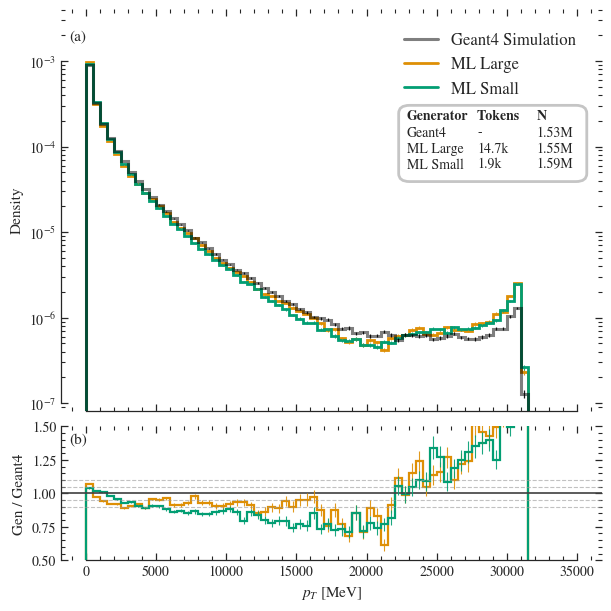

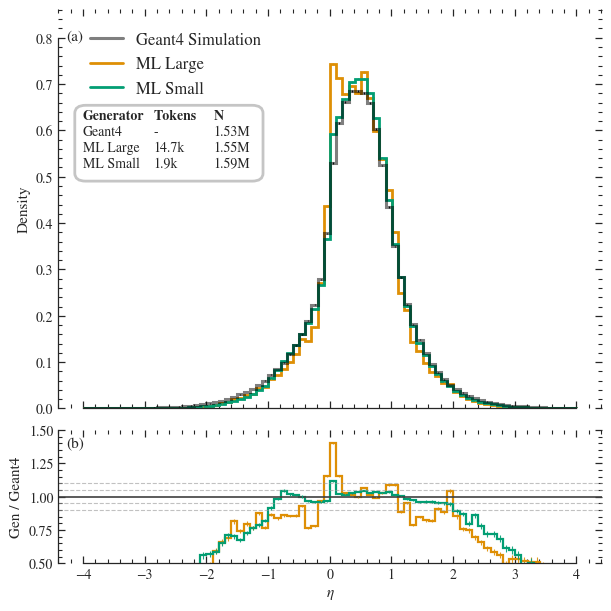

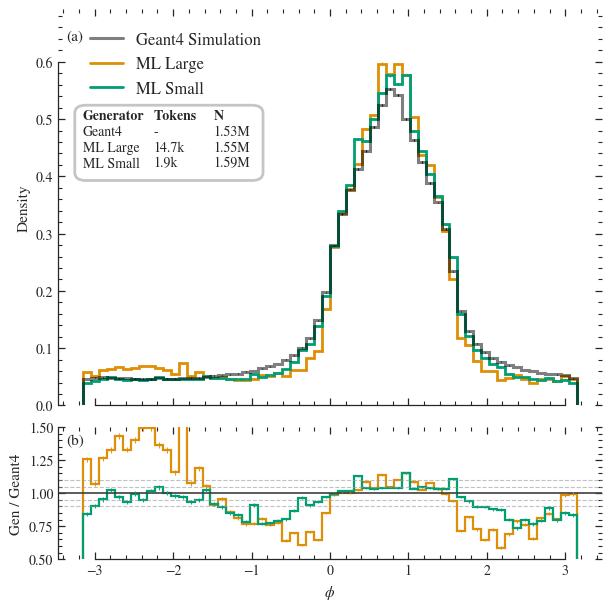

(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Density'>, <Axes: xlabel='$\\phi$', ylabel='Gen / Geant4'>))

In [30]:
all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

cn_data_dict = {}
for column_name in all_columns:
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=False)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=False)
        gen_data_dict[mn] = pdata_gen
        
    cn_data_dict[column_name] = (pdata_real, gen_data_dict)
    
# Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

# pt
cn = 'pt'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=True,
    out_file=None,
    title=None,
    show_output=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

cn = 'eta'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

cn = 'phi'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

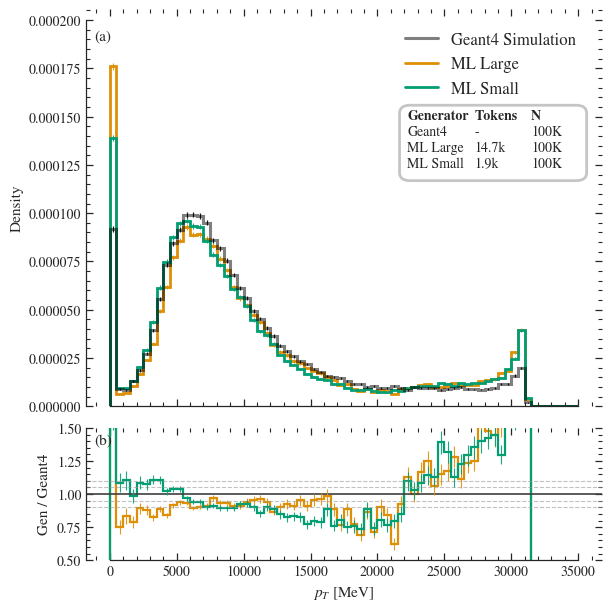

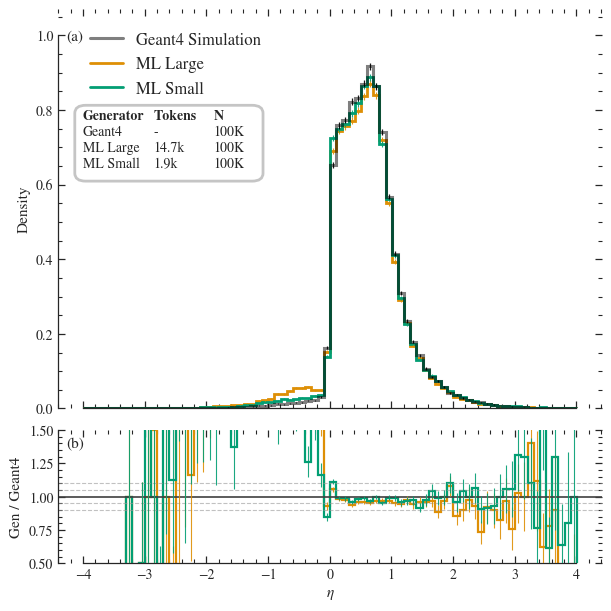

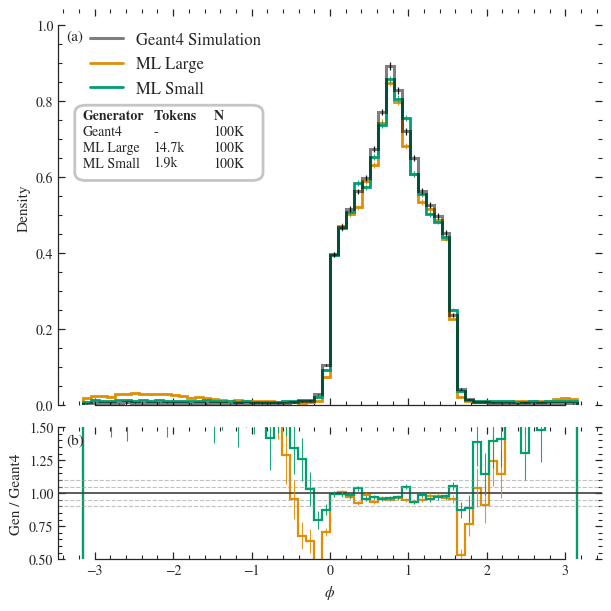

(<Figure size 600x600 with 2 Axes>,
 (<Axes: ylabel='Density'>, <Axes: xlabel='$\\phi$', ylabel='Gen / Geant4'>))

In [32]:
all_columns = ["pt", "eta", "phi"]
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

cn_data_dict = {}
for column_name in all_columns:
    # analysis_v2.dataset provides methods to easily extract a single column for analysis
    gen_data_dict = {}
    pdata_real = analv2.dataset.extract_single_column_for_analysis(real_verbose_data, column_name, return_only_leading=True)
    for mn in models_to_compare:
        pdata_gen = analv2.dataset.extract_single_column_for_analysis(gen_verbose_data_dict[mn], column_name, return_only_leading=True)
        gen_data_dict[mn] = pdata_gen
        
    cn_data_dict[column_name] = (pdata_real, gen_data_dict)
    
# Table by default has three rows: [Generator Name, Codebook Size, N data plotted]
spec_table_rows = [
    ("Geant4", "-", numerize.numerize(len(pdata_real))),
    ("ML Large", "14.7k", numerize.numerize(len(gen_data_dict['model_10M_9_exp9_vdimlr_1']))),
    ("ML Small", "1.9k", numerize.numerize(len(gen_data_dict['model_10M_12_inclrrestarts_3']))),
]

# pt
cn = 'pt'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

cn = 'eta'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

cn = 'phi'
analv2.plotting_v2.plot_dist_and_ratio_cont(
    column_name=cn,
    ref_vals=cn_data_dict[cn][0],
    comp_vals_dict=cn_data_dict[cn][1],
    model_legend_titles=models_legend_titles,
    edges=None,
    density=True,
    use_log=False,
    out_file=None,
    title=None,
    show_output=True,
    show_legend=True,
    # spec_text=spec_text,
    spec_table_rows=spec_table_rows,
)

### Exploration of parameters

In [16]:
model_names_and_labels = {
    'model_exp11_100k_lr1': '16.6M - 20M',
    'model_exp11_500k_lr1': '83M - 20M',
    'model_exp11_1M_lr1': '166M - 20M',
    'model_exp11_2M_lr1': '332M - 20M',
    'model_exp11_5M_lr1': '830M - 20M',
    'model_exp11_5M_lr1_tp2': '830M - 208M',
    'model_10M_9_exp9_vdimlr_1': '1.47B - 20M',
    'model_exp11_9M_lr1_tp2': '1.47B - 208M',
    'model_exp11_9M_lr1_tp3': '1.47B - 108M',
    'model_exp11_9M_lr1_tp4': '1.47B - 76M',
    'model_exp11_9M_lr1_tp6': '1.47B - 39M',
    'model_exp11_9M_lr1_tp5': '1.47B - 611M',
    'model_exp11_22M_lr1_tp1': '3.8B - 20M',
    'model_exp11_22M_lr1_tp2': '3.8B - 208M',
    'model_exp11_22M_lr1_tp3': '3.8B - 108M',
    'model_exp11_22M_lr1_tp4': '3.8B - 76M',
    'model_exp11_22M_lr1_tp6': '3.8B - 39M',
    'model_exp11_22M_lr1_tp5': '3.8B - 611M',
    'model_exp11_45M_lr1_tp1': 'N/A B - 20M',
    'model_exp11_45M_lr1_tp6': 'N/A B - 39M',
    'model_exp11_45M_lr1_tp4': 'N/A B - 76M',
    'model_exp11_45M_lr1_tp3': 'N/A B - 108M',
    'model_exp11_45M_lr1_tp2': 'N/A B - 208M',
    'model_exp11_45M_lr1_tp5': 'N/A B - 611M'
}

model_names = list(model_names_and_labels.keys())
model_labels = list(model_names_and_labels.values())

df = analv2.tables.get_default_df(model_names)
df["compute"] = df["num_params"] * df["batch_size"] * df["iters_saved"]

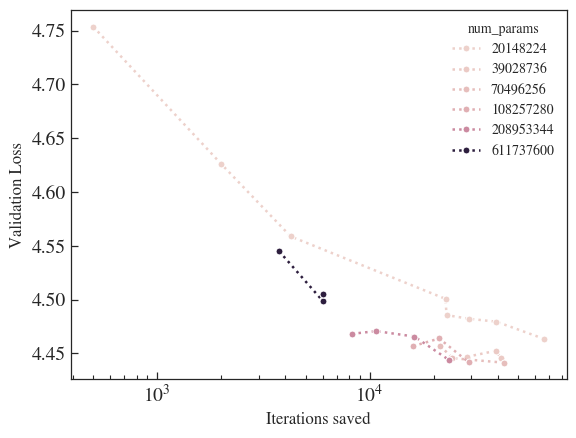

In [17]:
df_plot = df[["model_name", "iters_saved", "min_saved_val_loss", "num_train_tokens", "num_params", "batch_size", "compute"]].copy()
df_plot["num_params_label"] = df_plot["num_params"].map(lambda x: f"{x/1e6:.0f}M")

plt.figure()
sns.lineplot(
    data=df_plot, x="iters_saved", y="min_saved_val_loss", hue='num_params',
    marker="o", estimator=None, linestyle=':'
)
plt.xlabel("Iterations saved", fontsize=analv2.plotting_v2.axes_fontsize)
plt.ylabel("Validation Loss", fontsize=analv2.plotting_v2.axes_fontsize)
plt.xticks(fontsize=analv2.plotting_v2.ticks_fontsize)
plt.yticks(fontsize=analv2.plotting_v2.ticks_fontsize)
# plt.legend(title="Trainable Parameters", fontsize=analv2.plotting_v2.legend_fontsize)
plt.xscale("log")
plt.show()

#### Bubble scatter plot
- x = dataset size
- y = model size
- color = min_val_loss
- size = iterations

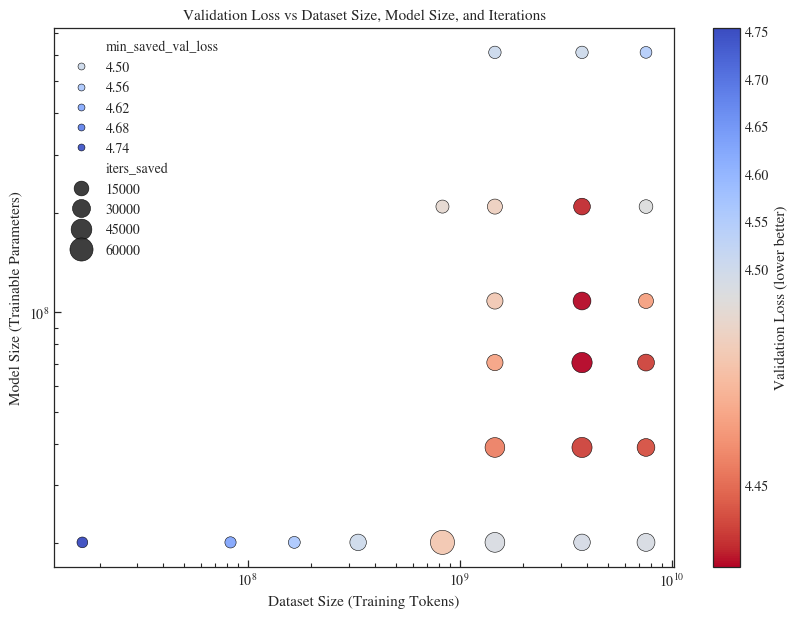

In [18]:
plot_df = df.copy()

norm = mcolors.TwoSlopeNorm(
    vmin=plot_df["min_saved_val_loss"].min(),
    vcenter=4.47,
    vmax=plot_df["min_saved_val_loss"].max()
)

fig, ax = plt.subplots(figsize=(10,7))

sns.scatterplot(
    data=plot_df,
    x="num_train_tokens",
    y="num_params",
    hue="min_saved_val_loss",
    palette="coolwarm_r",
    hue_norm=norm,
    size="iters_saved",
    sizes=(60, 300),
    edgecolor="black",
    linewidth=0.4,
    alpha=0.95,
    legend="brief",
    ax=ax
)

ax.set_xscale("log")
ax.set_yscale("log")

sm = cm.ScalarMappable(
    cmap="coolwarm_r",
    norm=norm
)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Validation Loss (lower better)")

ax.set_xlabel("Dataset Size (Training Tokens)")
ax.set_ylabel("Model Size (Trainable Parameters)")
ax.set_title("Validation Loss vs Dataset Size, Model Size, and Iterations")

plt.grid(False)
plt.show()

#### Heatmap grid by iteration bucket
- bin iters_saved
- make one heatmap per iteration range
- rows = model size
- columns = dataset size
- values = min_val_loss

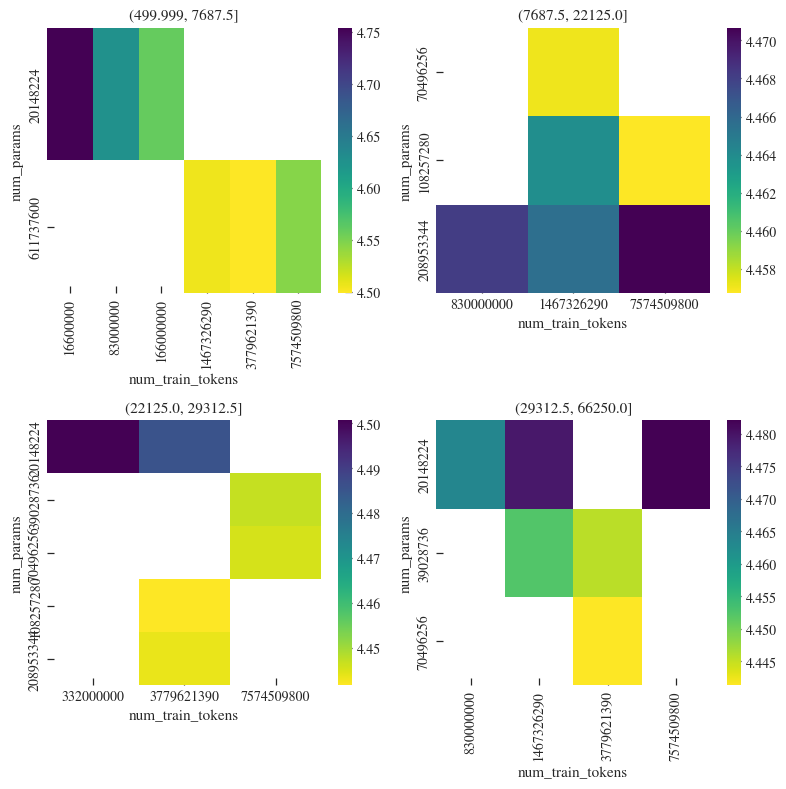

In [19]:
plot_df = df.copy()

if plot_df["num_params"].dtype == object:
    plot_df["num_params"] = (
        plot_df["num_params"]
        .str.replace("M", "", regex=False)
        .astype(float) * 1e6
    )

# Bucket iterations
plot_df["iters_bin"] = pd.qcut(plot_df["iters_saved"], q=4, duplicates="drop")

g = sns.FacetGrid(
    plot_df,
    col="iters_bin",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

def draw_heatmap(data, **kwargs):
    mat = data.pivot_table(
        index="num_params",
        columns="num_train_tokens",
        values="min_saved_val_loss",
        aggfunc="min"
    ).sort_index().sort_index(axis=1)

    sns.heatmap(mat, cmap="viridis_r", cbar=True)

g.map_dataframe(draw_heatmap)
g.set_titles("{col_name}")
plt.show()

#### Plot of tokens per parameter

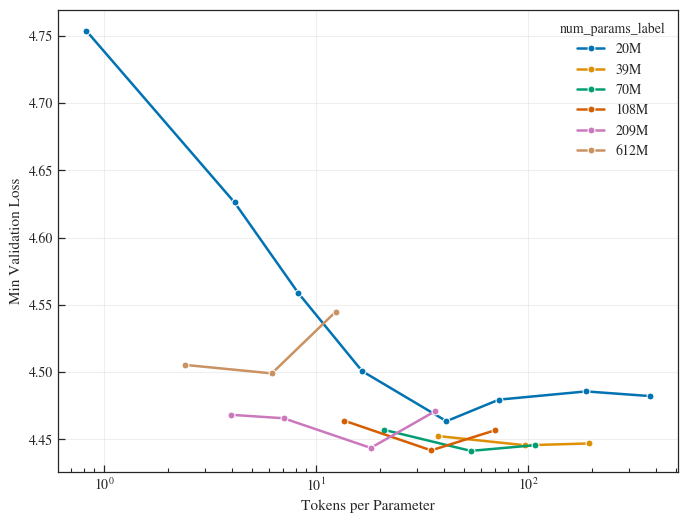

In [20]:
plot_df = df.copy()
plot_df["tokens_per_param"] = plot_df["num_train_tokens"] / plot_df["num_params"]

if plot_df["num_params"].dtype == object:
    plot_df["num_params"] = (
        plot_df["num_params"]
        .str.replace("M", "", regex=False)
        .astype(float) * 1e6
    )

plot_df["tokens_per_param"] = plot_df["num_train_tokens"] / plot_df["num_params"]
plot_df["num_params_label"] = plot_df["num_params"].map(lambda x: f"{x/1e6:.0f}M")

plt.figure(figsize=(8,6))
sns.lineplot(
    data=plot_df.sort_values(["num_params", "tokens_per_param"]),
    x="tokens_per_param",
    y="min_saved_val_loss",
    hue="num_params_label",
    marker="o",
    estimator=None
)
plt.xscale("log")
plt.xlabel("Tokens per Parameter")
plt.ylabel("Min Validation Loss")
plt.grid(True, alpha=0.3)
plt.show()